<a href="https://colab.research.google.com/github/220109cse-creat/logistic-and-linear/blob/main/logistic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)

print(" All libraries imported successfully.")


data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f"\n Dataset Shape : {df.shape}")
print(f" Classes       : {data.target_names}")
print(f"\n First 5 rows:")
print(df.head())

 All libraries imported successfully.

 Dataset Shape : (569, 31)
 Classes       : ['malignant' 'benign']

 First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980           

In [6]:
print("\n Missing Values per Column:")
print(df.isnull().sum())

X = df.drop('target', axis=1)
y = df['target']

print(f"\n Feature matrix X: {X.shape}")
print(f" Target vector y : {y.shape}")
print(f"\n Class distribution:\n{y.value_counts().rename({0:'Malignant', 1:'Benign'})}")

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"\n Split sizes:")
print(f"   Train      : {X_train.shape[0]} samples")
print(f"   Validation : {X_val.shape[0]} samples")
print(f"   Test       : {X_test.shape[0]} samples")


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("\n Features standardised (mean=0, std=1).")


 Missing Values per Column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

 Feature matrix X: (569, 30)
 Target vector y : (569,)

 C

In [7]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)
print("\n Logistic Regression model trained successfully.")


 Logistic Regression model trained successfully.




 EVALUATION METRICS (Test Set)
  Accuracy  : 0.9825  (98.25%)
  Precision : 0.9861
  Recall    : 0.9861
  F1-Score  : 0.9861
  AUC-ROC   : 0.9950

 Full Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

 Validation Accuracy: 0.9912  (99.12%)


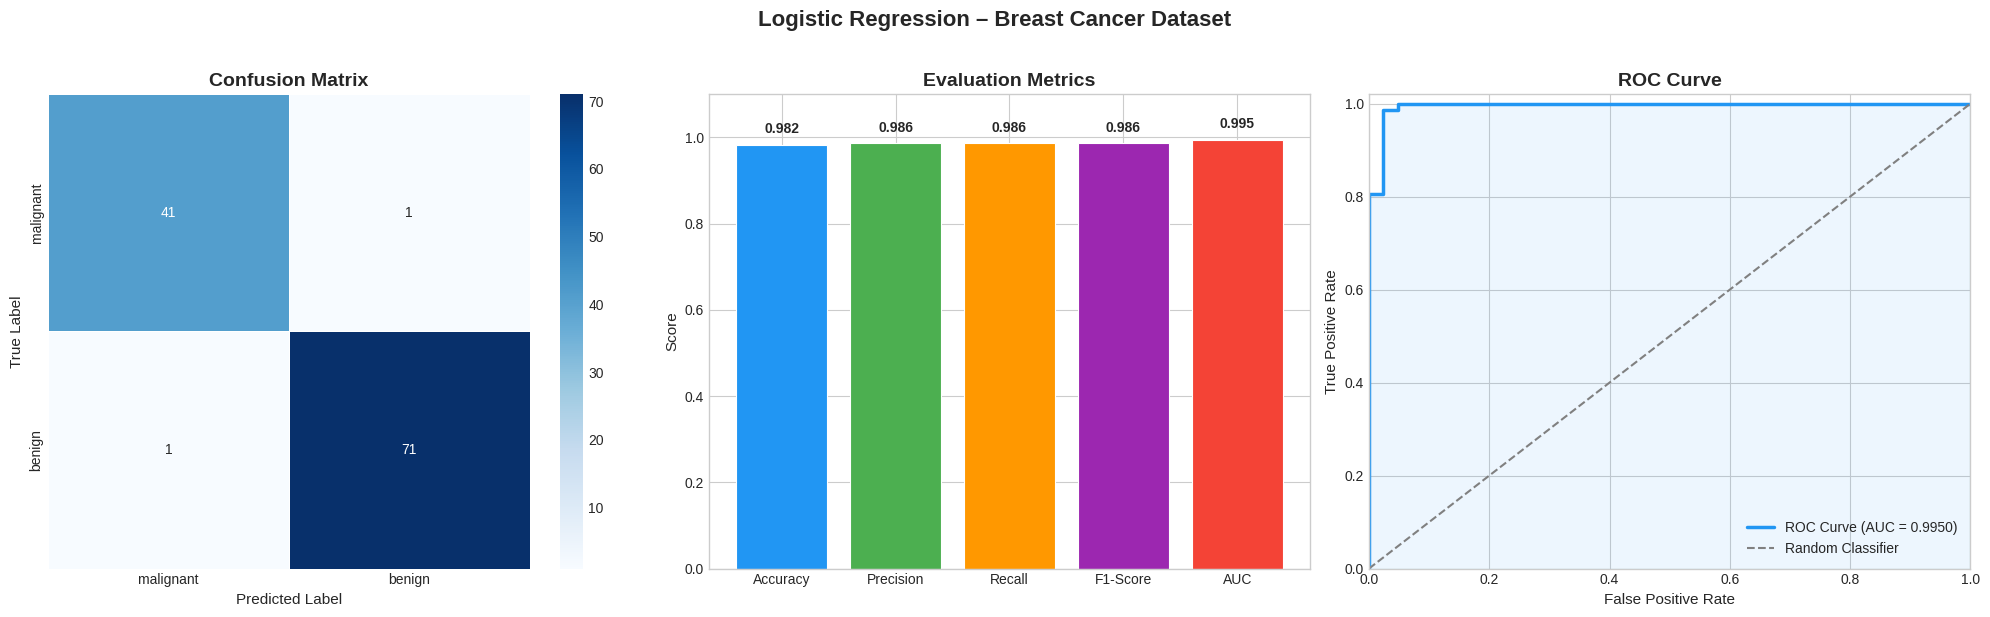


 Plots saved as 'logistic_regression_plots.png'


  SAMPLE PREDICTIONS (First 10 Test Samples)
   Actual Predicted  Prob_Malignant  Prob_Benign Correct
malignant malignant          1.0000       0.0000        
   benign    benign          0.0000       1.0000        
malignant malignant          0.9907       0.0093        
   benign    benign          0.4399       0.5601        
malignant malignant          1.0000       0.0000        
   benign    benign          0.0069       0.9931        
   benign    benign          0.0000       1.0000        
malignant malignant          1.0000       0.0000        
malignant malignant          0.9998       0.0002        
malignant malignant          1.0000       0.0000        
LOGISTIC REGRESSION SUMMARY
Dataset    : Breast Cancer Wisconsin
Samples    : 569  |  Features : 30
Split      : Train 60% / Val 20% / Test 20%
Accuracy   : 0.9825
Precision  : 0.9861
Recall     : 0.9861
F1-Score   : 0.9861
AUC-ROC    : 0.9950


In [8]:
y_pred       = model.predict(X_test_sc)
y_pred_proba = model.predict_proba(X_test_sc)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_proba)

print("\n")
print(" EVALUATION METRICS (Test Set)")
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")

print("\n Full Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=data.target_names))

y_val_pred = model.predict(X_val_sc)
val_acc = accuracy_score(y_val, y_val_pred)
print(f" Validation Accuracy: {val_acc:.4f}  ({val_acc*100:.2f}%)")

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Logistic Regression – Breast Cancer Dataset',
             fontsize=16, fontweight='bold', y=1.02)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names,
    linewidths=0.5, linecolor='white',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

metrics = {
    'Accuracy' : acc,
    'Precision': prec,
    'Recall'   : rec,
    'F1-Score' : f1,
    'AUC'      : auc
}
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = axes[1].bar(metrics.keys(), metrics.values(),
                   color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Evaluation Metrics', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=11)
for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[2].plot(fpr, tpr, color='#2196F3', lw=2.5,
             label=f'ROC Curve (AUC = {auc:.4f})')
axes[2].plot([0, 1], [0, 1], color='grey', lw=1.5,
             linestyle='--', label='Random Classifier')
axes[2].fill_between(fpr, tpr, alpha=0.08, color='#2196F3')
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1.02])
axes[2].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[2].set_xlabel('False Positive Rate', fontsize=11)
axes[2].set_ylabel('True Positive Rate', fontsize=11)
axes[2].legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('logistic_regression_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Plots saved as 'logistic_regression_plots.png'")

sample_df = pd.DataFrame({
    'Actual'           : [data.target_names[v] for v in y_test.values[:10]],
    'Predicted'        : [data.target_names[v] for v in y_pred[:10]],
    'Prob_Malignant'   : np.round(1 - y_pred_proba[:10], 4),
    'Prob_Benign'      : np.round(y_pred_proba[:10], 4),
    'Correct'          : ['' if a == p else ''
                          for a, p in zip(y_test.values[:10], y_pred[:10])]
})

print("\n" )
print("  SAMPLE PREDICTIONS (First 10 Test Samples)")
print(sample_df.to_string(index=False))

print("LOGISTIC REGRESSION SUMMARY")
print(f"Dataset    : Breast Cancer Wisconsin")
print(f"Samples    : {len(df)}  |  Features : {X.shape[1]}")
print(f"Split      : Train 60% / Val 20% / Test 20%")
print(f"Accuracy   : {acc:.4f}")
print(f"Precision  : {prec:.4f}")
print(f"Recall     : {rec:.4f}")
print(f"F1-Score   : {f1:.4f}")
print(f"AUC-ROC    : {auc:.4f}")
